# KNN Regression Activity (Baseline dataset)

In [19]:
from pathlib import Path
import pandas as pd

data_path = Path("../datasets/exam_score_baseline.csv")

if not data_path.exists():
    data_path = Path("exam_score_baseline.csv")

df = pd.read_csv(data_path)

## I - Define the Modeling Problem

**Target variable (y):**
- Exam score (`Exam_Score`)

**Predictors (X):**
- Number of hours studied (`Hours_Studied`)
- Percentage of class attendance (`Attendance_Percent`)
- Number of hours slept before exam (`Sleep_Hours`)
- Number of assignments completed (`Assignments_Completed`)

Each record's unique ID (`Synthetic_Record_ID`) is excluded because it is only an identifier.

In [20]:
numeric_features = [
    "Hours_Studied",
    "Attendance_Percent",
    "Sleep_Hours",
    "Assignments_Completed"
]

X = df[numeric_features]
y = df["Exam_Score"]

I am separating the data into the inputs and the answer I want to predict. `X` contains the four student features, and `y` contains the `Exam_Score` that the models will try to predict.

## II - Inspect Data Quality

This step checks the quality of the dataset before building the model. We are checking the dataset size, missing values, duplicate IDs, summary statistics, unusual observations, and relationships between variables.

### Records and Fields

Each **row** of the dataset is one observation (a student) and each **column** is one variable

In [21]:
# Count records and fields
print(f"Number of records (rows):   {df.shape[0]}")
print(f"Number of fields (columns): {df.shape[1]}")
print()
print("Column data types:")
print(df.dtypes)

Number of records (rows):   80
Number of fields (columns): 6

Column data types:
Synthetic_Record_ID       object
Hours_Studied            float64
Attendance_Percent         int64
Sleep_Hours              float64
Assignments_Completed      int64
Exam_Score                 int64
dtype: object


I am checking how much data I have and what type of data is in each column. The dataset has 80 students and 6 columns, which helps me understand the basic structure before I build a model.


### Missing Values

A missing value is a blank cell. We must verify that there are none in the dataset before modeling

In [22]:
# Detect missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing.to_string())
print(f"\nTotal missing cells: {missing.sum()}\n")

if (missing.sum() > 0): print("Missing values detected, data must be manually reviewed")
else: print ("No missing values detected, safe to proceed")

Missing values per column:
Synthetic_Record_ID      0
Hours_Studied            0
Attendance_Percent       0
Sleep_Hours              0
Assignments_Completed    0
Exam_Score               0

Total missing cells: 0

No missing values detected, safe to proceed


I am checking if any values are missing. Missing data can cause problems for a model, so I want to make sure every column has the information I need before moving forward.

### Duplicate Identifiers

If the same student appears twice under the same `Synthetic_Record_ID`, the model counts their data twice. We must remove any duplicates before modeling

In [23]:
# Detect duplicate records
num_dupes = df['Synthetic_Record_ID'].duplicated().sum()
print(f"Duplicate Synthetic_Record_IDs: {num_dupes}\n")

if (num_dupes): print("Duplicate indentifiers detected, manual review required")
else: print("No duplicated identifiers detected, safe to proceed")

Duplicate Synthetic_Record_IDs: 0

No duplicated identifiers detected, safe to proceed


I am checking whether the same student ID appears more than once. If the same record is repeated, it could unfairly influence the model, so I want to catch duplicates before modeling.

### Summary Statistics

Summary statistics compress each column into descriptive values that describe their shape

In [24]:
pd.set_option('display.precision', 2) # 2 decimal places
df.describe()

,Hours_Studied,Attendance_Percent,Sleep_Hours,Assignments_Completed,Exam_Score
count,80.00,80.00,80.00,80.00,80.00
mean,10.57,83.67,6.69,8.18,69.88
std,3.99,9.83,1.01,2.05,7.98
min,2.00,58.00,4.50,3.00,52.00
25%,7.85,76.00,6.00,7.00,65.00
50%,10.75,84.00,6.60,8.00,71.00
75%,13.15,91.00,7.33,10.00,75.00
max,20.00,100.00,9.20,12.00,87.00


I am looking at a quick summary of the numerical columns. This shows things like the average, minimum, maximum, and spread of the values so I can see whether the data looks reasonable.

### Plausible Value Ranges

Even with no missing values, a column can contain impossible values. For example, `Attendance_Percent` must be less than `100` and `Sleep_Hours` must be greater than `0`

In [25]:
# Define plausible value ranges
bounds = {
    'Hours_Studied':          (0, 24), # 0 - 24 hours studied
    'Attendance_Percent':     (0, 100), # 0 - 100 percent attendance
    'Sleep_Hours':            (0, 24), # 0 - 24 hours of sleep
    'Assignments_Completed':  (0, None), # 0 - infinity assignments completed
    'Exam_Score':             (0, 100), # 0 - 100 exam score
}

print("Plausible range check:")
all_clean = True
for col, (lo, hi) in bounds.items():
    mask = pd.Series(False, index=df.index)
    if lo is not None:
        mask |= (df[col] < lo)
    if hi is not None:
        mask |= (df[col] > hi)
    flagged = df.loc[mask, ['Synthetic_Record_ID', col]]
    if flagged.empty:
        print(f"  {col}: OK")
    else:
        print(f"  {col}: {len(flagged)} out-of-range value(s)")
        print(flagged.to_string(index=False))
        all_clean = False

if all_clean: print("\nAll values within plausible bounds, safe to proceed")
else: print("\nValues detected outside of their plausible bounds, manual review required")

Plausible range check:
  Hours_Studied: OK
  Attendance_Percent: OK
  Sleep_Hours: OK
  Assignments_Completed: OK
  Exam_Score: OK

All values within plausible bounds, safe to proceed


Here, I am checking whether the values make sense in real terms. For example, attendance should stay between 0 and 100 and exam scores should also stay between 0 and 100. This helps me catch impossible values before using the data.

### Variable Correlation

Correlation shows the strength and direction of the linear relationship between two numerical variables

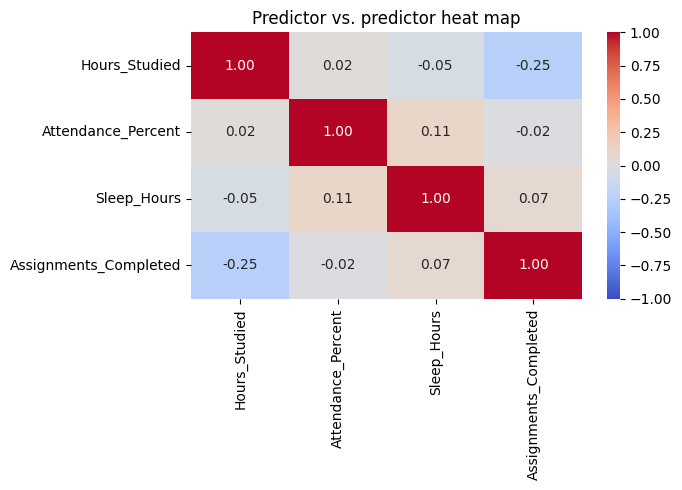

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['Hours_Studied', 'Attendance_Percent', 'Sleep_Hours',
                'Assignments_Completed']

# --- Correlation heatmap ---
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Predictor vs. predictor heat map')
plt.tight_layout()
plt.show()

I am checking how strongly the predictor variables are related to each other. Values close to 0 mean there is not much linear relationship, while values closer to 1 or -1 mean the variables move together more strongly. I want to make sure I do not have predictors that are basically giving the model the same information twice.

In the above heatmap, correlation is represented by a value ranging from `-1` to `1`

- **Closer to `+1`:** *Strong positive relationship* - as one variable increases, the other increases
- **Closer to `-1`:** *Strong negative relationship* - as one variable increases, the other decreases
- **Closer to `0`:** *Weak linear relationship* - little to no correlation between the two variables

Highly correlated predictors are those that tend to move closely together. Within KNN, this can cause *"double weighting,"* where neighbors are pulled in a direction twice as much as they should be due to two predictors essentially measuring the same thing. Highly correlated predictors do not pose as much of an issue in KNN as they do in linear regression, but they are still worth checking for.

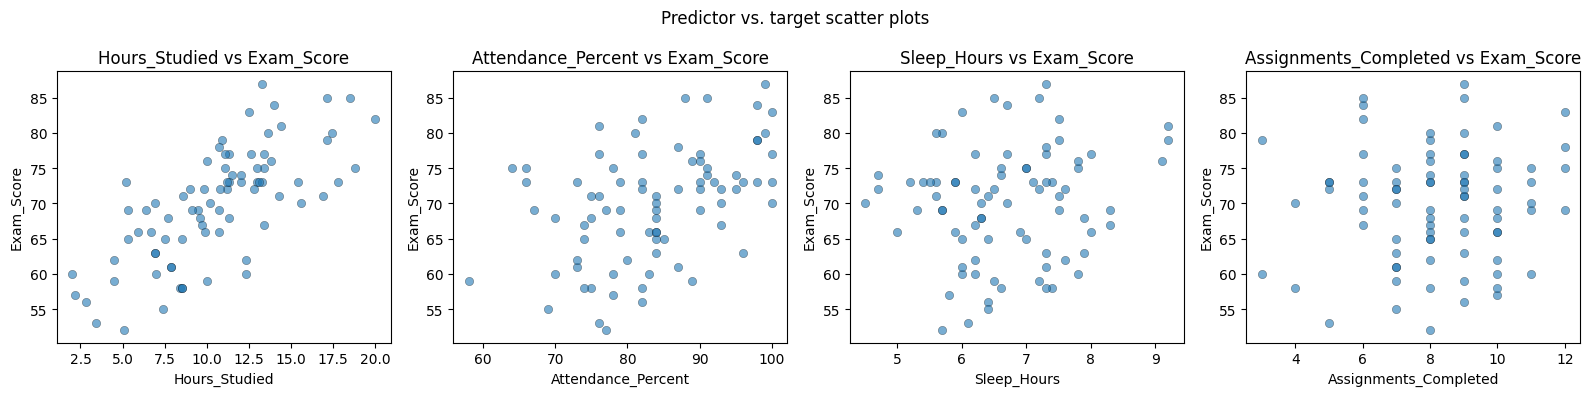

In [27]:
# --- Scatter plots: each predictor vs. Exam_Score ---
predictors = ['Hours_Studied', 'Attendance_Percent', 'Sleep_Hours', 'Assignments_Completed']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, predictors):
    ax.scatter(df[col], df['Exam_Score'], alpha=0.6, edgecolors='k', linewidths=0.3)
    ax.set_xlabel(col)
    ax.set_ylabel('Exam_Score')
    ax.set_title(f'{col} vs Exam_Score')
plt.suptitle('Predictor vs. target scatter plots')
plt.tight_layout()
plt.show()

I am comparing each predictor with `Exam_Score` to see the general pattern. An upward pattern means higher values of that predictor tend to go with higher exam scores. In this dataset, `Hours_Studied` shows the clearest positive pattern.

In the above scatter plots, a positive correlation between a predictor and the target is represented by a consistent upward trend

Predictor **Hours_Studied** shows the strongest positive correlation with target **Exam_Score**; **Assignments_Completed** shows the weakest

### Outlier Detection

An outlier is a value that sits far from the rest of the data. An outlier can pull the entire fitted line toward it and skew the model.

In [28]:
# --- IQR-based outlier flagging ---
outlier_rows = []

for col in numeric_features + ["Exam_Score"]:
    Q1 = df[col].quantile(0.25) # 25th percentile (75% scored above)
    Q3 = df[col].quantile(0.75) # 75th percentile (25% scored above)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_rows.append({
        'Column': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': round(IQR, 3),
        'Lower fence': round(lower, 3),
        'Upper fence': round(upper, 3),
        'Outliers flagged': n_out
    })

outlier_df = pd.DataFrame(outlier_rows).set_index('Column')
outlier_df

,Q1,Q3,IQR,Lower fence,Upper fence,Outliers flagged
Column,,,,,,
Hours_Studied,7.85,13.15,5.30,-0.10,21.10,0
Attendance_Percent,76.00,91.00,15.00,53.50,113.50,0
Sleep_Hours,6.00,7.33,1.32,4.01,9.31,0
Assignments_Completed,7.00,10.00,3.00,2.50,14.50,0
Exam_Score,65.00,75.00,10.00,50.00,90.00,0


I am checking for values that are far away from most of the other data. The IQR method gives me a lower and upper limit for each column, and anything outside those limits is flagged as a possible outlier.

The IQR method defines the fences as:

- **Lower fence:** Q1 − 1.5 × IQR
- **Upper fence:** Q3 + 1.5 × IQR

Any value outside these bounds is a potential outlier. No outlier values were detected across all predictors

#### Data Quality Analysis

- The dataset contains **80** records and **6** fields
    - **5** predictors and **1** target
- No missing values or duplicate identifiers were found
- The numerical variables fall within reasonable ranges with no obvious abnormalities
- No two predictors had a strong correlation with one another
- **Hours_Studied** had the strongest positive correlation with **Exam_Score** while **Assignments_Completed** had the weakest
- No outlier values were detected across all predictors

# Task 2: Predict the Effect of Scale

kNN finds the data points that are closest to each other.

Some predictors have much larger number ranges than others. In our dataset, Attendance_Percent has the largest range, so it could have more influence on the distance calculation just because its numbers are bigger.

Standardizing puts the predictors on a similar scale. This helps kNN compare the predictors more fairly and can change which data points are considered the nearest neighbors.

In [29]:
for feature in numeric_features:
    feature_range = df[feature].max() - df[feature].min()
    print(feature, "range:", feature_range)

Hours_Studied range: 18.0
Attendance_Percent range: 42
Sleep_Hours range: 4.699999999999999
Assignments_Completed range: 9


I am finding the numerical range of each predictor because kNN uses distance. `Attendance_Percent` has the largest range, so without scaling it could affect the distance more just because its numbers are larger.

# Task 3: Prepare the Predictors

All four predictors in the Group 1 baseline dataset are numerical, so no categorical encoding is needed.

The predictors will stay in their original form for now. Scaling will be done later inside the kNN pipeline so that the scaler only uses the training data.

# Task 4: Compare Linear Regression and kNN


In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RepeatedKFold, cross_validate

repeated_cv = RepeatedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=407
)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

def evaluate_model(name, model):
    scores = cross_validate(
        model,
        X,
        y,
        cv=repeated_cv,
        scoring=scoring
    )

    return {
        "Model": name,
        "MAE Mean": -scores["test_MAE"].mean(),
        "MAE SD": scores["test_MAE"].std(),
        "RMSE Mean": -scores["test_RMSE"].mean(),
        "RMSE SD": scores["test_RMSE"].std(),
        "R2 Mean": scores["test_R2"].mean(),
        "R2 SD": scores["test_R2"].std(),
    }

I am setting up a fair way to test every model. The data is split into 5 parts and this process is repeated 5 times, giving 25 test results. I then compare the models using MAE, RMSE, and R² instead of judging them from only one train/test split.

In [31]:
linear_model = LinearRegression()

knn5_unscaled = KNeighborsRegressor(
    n_neighbors=5,
    weights="uniform"
)

knn5_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(
        n_neighbors=5,
        weights="uniform"
    )),
])

scaling_results = pd.DataFrame([
    evaluate_model("Linear Regression", linear_model),
    evaluate_model("kNN k=5 Unscaled", knn5_unscaled),
    evaluate_model("kNN k=5 Scaled", knn5_scaled),
])

scaling_results

,Model,MAE Mean,MAE SD,RMSE Mean,RMSE SD,R2 Mean,R2 SD
0,Linear Regression,3.08,0.46,3.77,0.51,0.75,0.06
1,kNN k=5 Unscaled,4.27,0.51,5.13,0.54,0.55,0.09
2,kNN k=5 Scaled,4.39,0.49,5.28,0.51,0.52,0.12


I am comparing three starting models: Linear Regression, kNN with `k = 5` without scaling, and kNN with `k = 5` after scaling. I use the same evaluation method for all three so the comparison is fair. In these results, Linear Regression has the lowest RMSE and highest R², so it performs best at this stage.

# Task 5: Tune k for Scaled kNN

In [32]:
candidate_k = [1, 3, 5, 9, 15]

k_results = []

for k in candidate_k:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(
            n_neighbors=k,
            weights="uniform"
        )),
    ])

    result = evaluate_model(f"kNN k={k} Scaled", model)
    k_results.append(result)

k_results_df = pd.DataFrame(k_results)

k_results_df

,Model,MAE Mean,MAE SD,RMSE Mean,RMSE SD,R2 Mean,R2 SD
0,kNN k=1 Scaled,5.24,0.84,6.31,0.86,0.30,0.22
1,kNN k=3 Scaled,4.66,0.65,5.62,0.61,0.45,0.14
2,kNN k=5 Scaled,4.39,0.49,5.28,0.51,0.52,0.12
3,kNN k=9 Scaled,4.30,0.52,5.07,0.58,0.56,0.06
4,kNN k=15 Scaled,4.31,0.43,5.19,0.52,0.54,0.06


I am testing several values of `k` to see how many neighbors work best for kNN. A very small `k` can react too much to individual points, while a very large `k` can smooth the predictions too much. I compare the RMSE for each choice and look for the lowest one.

In [33]:
best_row = k_results_df.loc[k_results_df["RMSE Mean"].idxmin()]

selected_k = int(
    best_row["Model"]
    .replace("kNN k=", "")
    .replace(" Scaled", "")
)

print("Selected k:", selected_k)
print()
print(best_row)

Selected k: 9

Model        kNN k=9 Scaled
MAE Mean                4.3
MAE SD                 0.52
RMSE Mean              5.07
RMSE SD                0.58
R2 Mean                0.56
R2 SD                  0.06
Name: 3, dtype: object


I am automatically selecting the `k` value with the lowest mean RMSE. The best result is `k = 9`, so I will use 9 neighbors in the next step.

I am automatically selecting the `k` value with the lowest mean RMSE. The best result is `k = 9`, so I will use 9 neighbors in the next step.

# Task 6: Compare Neighbor Weighting

In [34]:
weight_results = []

for weight in ["uniform", "distance"]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(
            n_neighbors=selected_k,
            weights=weight
        )),
    ])

    result = evaluate_model(
        f"kNN k={selected_k} {weight}",
        model
    )

    weight_results.append(result)

weight_results_df = pd.DataFrame(weight_results)

weight_results_df

,Model,MAE Mean,MAE SD,RMSE Mean,RMSE SD,R2 Mean,R2 SD
0,kNN k=9 uniform,4.30,0.52,5.07,0.58,0.56,0.06
1,kNN k=9 distance,4.24,0.52,5.02,0.55,0.57,0.07


Now I keep `k = 9` and test two ways of using the neighbors. `Uniform` gives every neighbor the same importance, while `distance` gives closer neighbors more importance. I compare the results to see which weighting method predicts better.

Distance weighting performed slightly better than uniform weighting. It had a lower mean RMSE (5.015 compared with 5.071) and a slightly higher mean R² (0.571 compared with 0.563). This suggests that giving closer neighbors more influence slightly improved estimated generalization.

## Task 7: Diagnostic Plot and Final Model Comparison

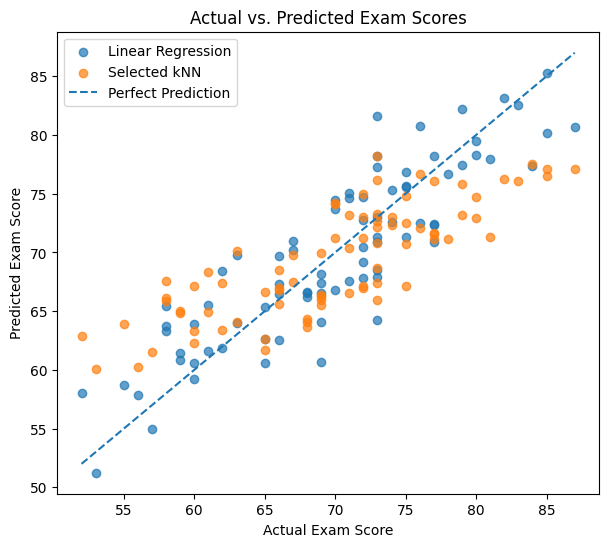

In [35]:
from sklearn.model_selection import KFold, cross_val_predict
import matplotlib.pyplot as plt

prediction_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=407
)

final_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(
        n_neighbors=selected_k,
        weights="distance"
    )),
])

lr_predictions = cross_val_predict(
    linear_model,
    X,
    y,
    cv=prediction_cv
)

knn_predictions = cross_val_predict(
    final_knn,
    X,
    y,
    cv=prediction_cv
)

plt.figure(figsize=(7, 6))

plt.scatter(y, lr_predictions, alpha=0.7, label="Linear Regression")
plt.scatter(y, knn_predictions, alpha=0.7, label="Selected kNN")

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs. Predicted Exam Scores")
plt.legend()
plt.show()

**What this graph is showing:**  
I am comparing the actual exam scores with the scores predicted by Linear Regression and the final kNN model. The dashed line represents a perfect prediction, so points closer to that line are better. This gives me a visual way to see how closely each model matches the real scores.

In [36]:
final_comparison = pd.DataFrame([
    evaluate_model("Linear Regression", linear_model),
    evaluate_model(
        f"kNN k={selected_k} distance",
        final_knn
    )
])

final_comparison

,Model,MAE Mean,MAE SD,RMSE Mean,RMSE SD,R2 Mean,R2 SD
0,Linear Regression,3.08,0.46,3.77,0.51,0.75,0.06
1,kNN k=9 distance,4.24,0.52,5.02,0.55,0.57,0.07


I am making the final side-by-side comparison between Linear Regression and my best kNN model (`k = 9` with distance weighting). Linear Regression has the lower RMSE and higher R², so it gives better predictions for this Group 1 dataset.

### Final Interpretation

The best kNN model used **k = 9** with **distance weighting**. Distance weighting worked a little better than uniform weighting.

However, **Linear Regression performed better overall**. Linear Regression had a lower RMSE of about **3.77**, while kNN had an RMSE of about **5.02**. Linear Regression also had a higher R² of about **0.75**, compared with about **0.57** for kNN. This means Linear Regression was better at predicting exam scores for this dataset.

For kNN, the results got better as k increased from 1 to 9. At k = 15, the results got slightly worse. This shows that using too few or too many neighbors can affect how well the model performs.

Group 1 used the clean baseline dataset, so there were no added outliers, categorical variables, or other changes to the data.

One limitation is that the dataset only has **80 students** and the data is synthetic. Because of this, the results may be different with real student data or a larger dataset.

The results show that things like study hours, attendance, sleep, and assignments are related to exam scores in this dataset. However, this does not mean that changing one of these things will directly cause a student's exam score to change.
